## Load Forecast vs. rtm price correlation

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DATA_ROOT = Path('../..').resolve() / "01_data"
LOAD_FORECAST = PROJECT_DATA_ROOT / "2_cleaned" / "load" / "forecast" / "Hourly ERCOT system load and prediction 20220201 20251201.csv"
RTM_PRICE = PROJECT_DATA_ROOT / "2_cleaned" / "rtm_price" / "rtm_price_aggregated_2021_2025.csv"
OUT_DIR = PROJECT_DATA_ROOT / "3_analysis" / "load_forecast"
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
df_rtm = pd.read_csv(RTM_PRICE)
df_load = pd.read_csv(LOAD_FORECAST)
df_load.rename(columns={'actual_ERCOT': 'actual_load', 'error_ERCOT': 'load_forecast_error'}, inplace=True)
df_rtm

,date_time,avg_rtm_price,std_rtm_price
0,2021-01-01 01:00:00,18.714000,1.508854
1,2021-01-01 02:00:00,18.107333,1.512517
2,2021-01-01 03:00:00,17.570000,1.537424
3,2021-01-01 04:00:00,17.670667,1.540869
4,2021-01-01 05:00:00,17.792000,1.997417
...,...,...,...
43310,2025-12-27 20:00:00,17.682000,4.066851
43311,2025-12-27 21:00:00,15.002667,4.357721
43312,2025-12-27 22:00:00,13.227333,4.750020
43313,2025-12-27 23:00:00,14.328667,5.222993


In [43]:
# merge
df_load['datetime'] = pd.to_datetime(df_load['datetime'])
df_rtm['date_time'] = pd.to_datetime(df_rtm['date_time'])
df = df_rtm.merge(df_load, left_on='date_time', right_on='datetime', how='inner')
df = df.drop(columns=['date_time', 'std_rtm_price'])
df.set_index('datetime', inplace=True)
df

,avg_rtm_price,actual_load,load_forecast_error
datetime,,,
2022-02-01 01:00:00,13.662000,35709.832031,-561.832031
2022-02-01 02:00:00,12.867333,34733.136719,-679.136719
2022-02-01 03:00:00,14.420667,34448.484375,-946.484375
2022-02-01 04:00:00,18.360667,34471.617188,-837.617188
2022-02-01 05:00:00,21.484667,35127.335938,-571.335938
...,...,...,...
2025-11-30 20:00:00,73.665333,55294.851563,-1311.851563
2025-11-30 21:00:00,72.008000,54523.589844,-36.589844
2025-11-30 22:00:00,74.346667,53437.218750,1104.781250


In [44]:
# error in absolute value
df['abs_load_error'] = abs(df['load_forecast_error'])
df

,avg_rtm_price,actual_load,load_forecast_error,abs_load_error
datetime,,,,
2022-02-01 01:00:00,13.662000,35709.832031,-561.832031,561.832031
2022-02-01 02:00:00,12.867333,34733.136719,-679.136719,679.136719
2022-02-01 03:00:00,14.420667,34448.484375,-946.484375,946.484375
2022-02-01 04:00:00,18.360667,34471.617188,-837.617188,837.617188
2022-02-01 05:00:00,21.484667,35127.335938,-571.335938,571.335938
...,...,...,...,...
2025-11-30 20:00:00,73.665333,55294.851563,-1311.851563,1311.851563
2025-11-30 21:00:00,72.008000,54523.589844,-36.589844,36.589844
2025-11-30 22:00:00,74.346667,53437.218750,1104.781250,1104.781250


/Users/zyliazhang/Git/RESEARCH-PJM-ERCOT-Price-Volatility/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'Load Prediction Error')

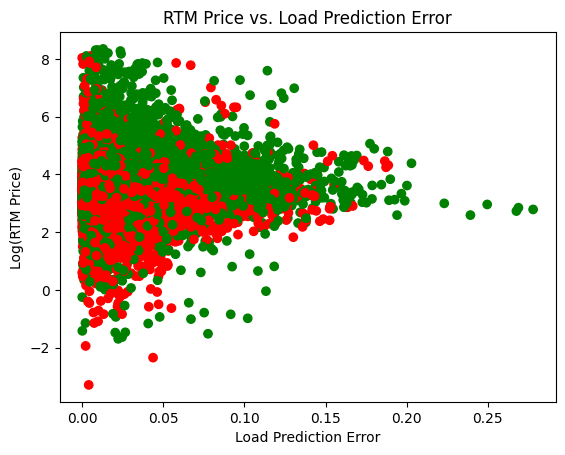

In [45]:
# investigate negative + positive predictions
# error = predicted - actual 

colors = np.where(df['load_forecast_error'] >= 0, 'green', 'red')

plt.scatter(df["abs_load_error"]/df['actual_load'], np.log(df["avg_rtm_price"]), c=colors)
plt.title('RTM Price vs. Load Prediction Error')
plt.ylabel('Log(RTM Price)')
plt.xlabel('Load Prediction Error')

Text(0.5, 0, 'Load')

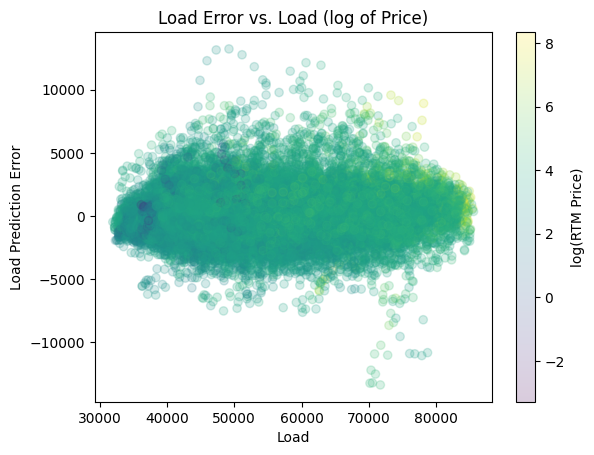

In [46]:
# error vs. load (color log price)

sc = plt.scatter(df['actual_load'], df['load_forecast_error'], alpha=0.2, c=np.log(df['avg_rtm_price']))
plt.colorbar(sc, label='log(RTM Price)')
plt.title('Load Error vs. Load (log of Price)')
plt.ylabel('Load Prediction Error')
plt.xlabel('Load')

In [47]:
df.describe()

,avg_rtm_price,actual_load,load_forecast_error,abs_load_error
count,33411.000000,33357.000000,33357.000000,33357.000000
mean,46.912971,52624.958524,91.928064,1261.678999
std,126.764806,11202.112381,1734.900783,1194.340876
min,-2.656667,31955.060547,-13370.523438,0.089844
25%,18.833000,44189.558594,-928.363281,446.757812
50%,27.455333,49976.261719,-16.523438,949.851563
75%,45.033333,59471.500000,974.460937,1697.605469
max,4203.718000,85558.984375,13228.574219,13370.523438


Text(0.5, 0, 'Load')

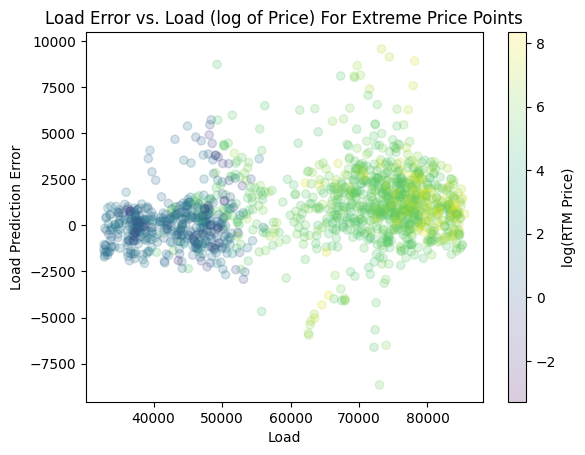

In [48]:
# filter to extreme prices
# error vs. load (color log price)

df_filter = df[(df['avg_rtm_price'] < 5) | (df['avg_rtm_price'] > 150)]

colors = np.sign(df_filter['avg_rtm_price']) * np.log(abs(df_filter['avg_rtm_price']))
sc = plt.scatter(df_filter['actual_load'], df_filter['load_forecast_error'], alpha=0.2, c=colors)
plt.colorbar(sc, label='log(RTM Price)')
plt.title('Load Error vs. Load (log of Price) For Extreme Price Points')
plt.ylabel('Load Prediction Error')
plt.xlabel('Load')

Text(0.5, 0.98, 'Load Forecast Error vs. Actual Load Over Year (Log of Price)')

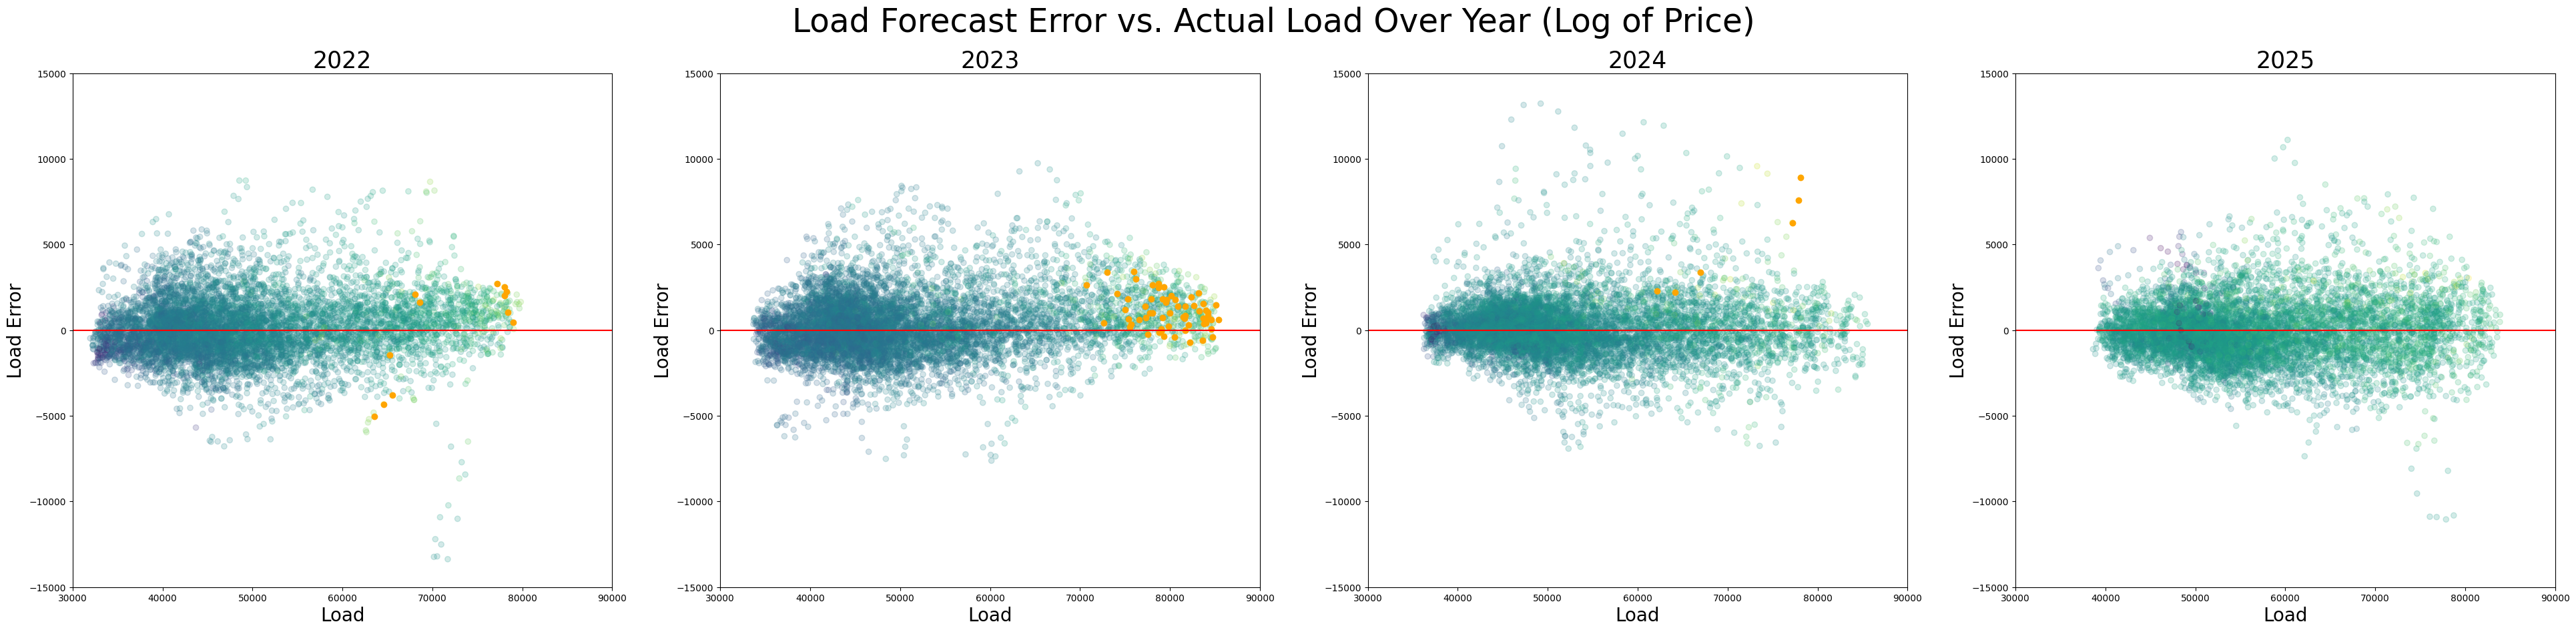

In [49]:
years = [2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 4, figsize=(48, 10))
axes = axes.flatten()

for ax, year in zip(axes, years):
    year_data = df[df.index.year == year]
    color_vals = np.sign(year_data['avg_rtm_price']) * np.log1p(np.abs(year_data['avg_rtm_price']))
    ax.scatter(year_data['actual_load'], year_data['load_forecast_error'], alpha=0.2, c=color_vals)
    
    # highlight extreme values
    high_prices = year_data[color_vals > 7]
    ax.scatter(high_prices['actual_load'], high_prices['load_forecast_error'], c='orange')
    ax.hlines(0, 30000, 90000, colors='red')
    ax.set_title(year, fontsize=25)
    ax.set_ylim(-15000, 15000)
    ax.set_xlim(30000, 90000)
    ax.set_ylabel('Load Error', fontsize=20)
    ax.set_xlabel('Load', fontsize=20)

fig.suptitle('Load Forecast Error vs. Actual Load Over Year (Log of Price)', fontsize=35)

Text(0.5, 0, 'Actual Load (MW)')

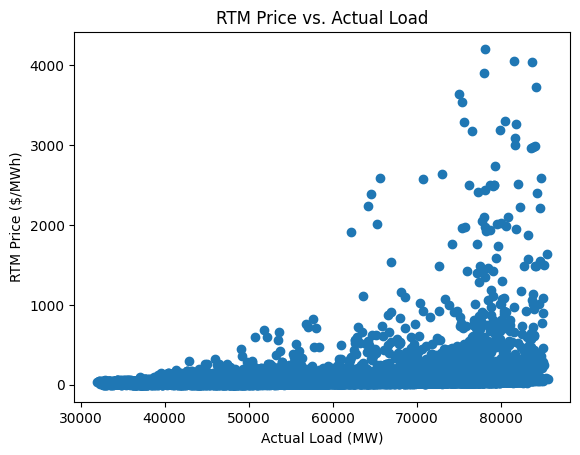

In [50]:
plt.scatter(df["actual_load"], df["avg_rtm_price"])
plt.title('RTM Price vs. Actual Load')
plt.ylabel('RTM Price ($/MWh)')
plt.xlabel('Actual Load (MW)')

(array([18993., 19174., 19358., 19539., 19723., 19905., 20089., 20270.,
        20454.]),
 [Text(18993.0, 0, '2022-01'),
  Text(19174.0, 0, '2022-07'),
  Text(19358.0, 0, '2023-01'),
  Text(19539.0, 0, '2023-07'),
  Text(19723.0, 0, '2024-01'),
  Text(19905.0, 0, '2024-07'),
  Text(20089.0, 0, '2025-01'),
  Text(20270.0, 0, '2025-07'),
  Text(20454.0, 0, '2026-01')])

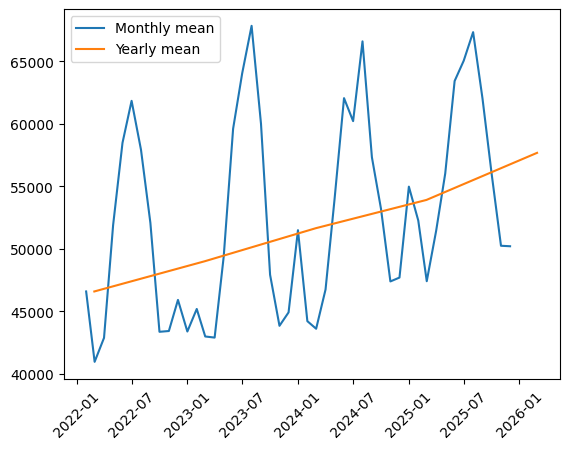

In [18]:
# load as a function of time

# resample by month
monthly_df = df.resample('MS').mean()

# resample by year
yearly_df = df.resample('YE-FEB').mean()

plt.plot(monthly_df.index, monthly_df['actual_load'], label='Monthly mean')
plt.plot(yearly_df.index, yearly_df['actual_load'], label='Yearly mean')
plt.legend()
plt.xticks(rotation=45)

(array([18993., 19174., 19358., 19539., 19723., 19905., 20089., 20270.,
        20454.]),
 [Text(18993.0, 0, '2022-01'),
  Text(19174.0, 0, '2022-07'),
  Text(19358.0, 0, '2023-01'),
  Text(19539.0, 0, '2023-07'),
  Text(19723.0, 0, '2024-01'),
  Text(19905.0, 0, '2024-07'),
  Text(20089.0, 0, '2025-01'),
  Text(20270.0, 0, '2025-07'),
  Text(20454.0, 0, '2026-01')])

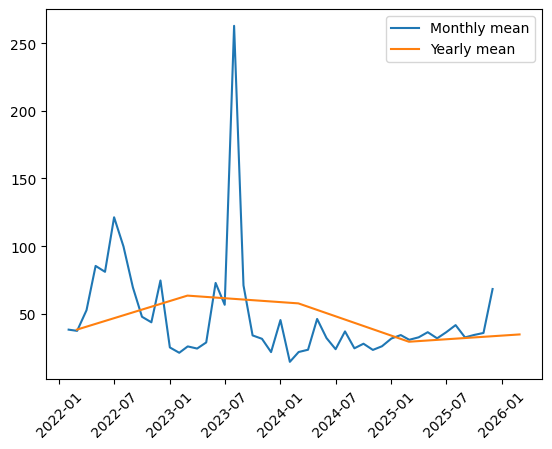

In [ ]:
# rtm price as a function of time

plt.plot(monthly_df.index, monthly_df['avg_rtm_price'], label='Monthly mean')
plt.plot(yearly_df.index, yearly_df['avg_rtm_price'], label='Yearly mean')
plt.legend()
plt.xticks(rotation=45)